# Personal Portfolio Optimization – Markowitz Mean-Variance Model

This notebook implements a portfolio optimization framework applied to my personal investment portfolio.

The objective is to estimate optimal asset weights using modern portfolio theory (Markowitz model).  
The analysis follows several steps:

1. Load the current portfolio holdings
2. Download historical market data for each asset
3. Compute asset returns
4. Estimate the covariance matrix of returns
5. Solve the portfolio optimization problem
6. Compare the optimal allocation with the current portfolio

The optimization problem minimizes portfolio variance subject to portfolio constraints.

## Environment Setup

The following libraries are used in the analysis:

- NumPy for numerical computations
- Pandas for data manipulation
- CVXPY for portfolio optimization
- Matplotlib for visualization

In [58]:
# Install optimization library (used in the lab)
!pip install cvxpy
import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt

## 3. Load Personal Portfolio Holdings

In this section we define the assets included in the portfolio.

Historical market data for these assets will be downloaded from Yahoo Finance and used to compute returns, risk, and optimal portfolio allocations.

In [59]:
!pip install yfinance

In [60]:
import yfinance as yf

tickers = [
    "NVDA",
    "GOOGL",
    "AMZN",
    "O",
    "OGS",
    "AIR.PA",
    "RHM.DE",
    "SPXS"
]

tickers

['NVDA', 'GOOGL', 'AMZN', 'O', 'OGS', 'AIR.PA', 'RHM.DE', 'SPXS']

## 4. Download Historical Price Data

In this section, we download historical adjusted closing prices for the selected portfolio assets from Yahoo Finance.

These price series will be used to compute daily returns and estimate the risk characteristics of the portfolio.

In [61]:
prices = yf.download(
    tickers,
    start="2019-01-01",
    auto_adjust=True,
    progress=False
)["Close"]

In [62]:
prices.head()

Ticker,AIR.PA,AMZN,GOOGL,NVDA,O,OGS,RHM.DE,SPXS
Date,,,,,,,,
2019-01-02,77.553207,76.956497,52.301720,3.377167,42.727200,60.841278,70.270660,2675.685303
2019-01-03,74.825912,75.014000,50.853203,3.173128,43.106674,61.150730,67.287140,2877.230225
2019-01-04,78.428543,78.769501,53.461636,3.376422,43.092873,61.666557,71.183266,2582.731445
2019-01-07,76.991165,81.475502,53.355022,3.555172,42.968674,61.349121,72.517082,2523.657959
2019-01-08,79.838257,82.829002,53.823650,3.466665,43.596531,62.475983,72.446877,2453.290527


In [63]:
prices.tail()

Ticker,AIR.PA,AMZN,GOOGL,NVDA,O,OGS,RHM.DE,SPXS
Date,,,,,,,,
2026-03-05,175.880005,218.940002,300.668335,183.339996,64.800003,86.750000,1547.0,35.970001
2026-03-06,175.500000,213.210007,298.309998,177.820007,65.000000,87.050003,1592.5,37.430000
2026-03-09,175.419998,213.490005,306.359985,182.649994,64.940002,87.150002,1625.0,36.459999
2026-03-10,177.899994,214.330002,307.040009,184.770004,64.879997,86.230003,1653.0,36.680000
2026-03-11,174.919998,NaN,NaN,NaN,NaN,NaN,1556.5,NaN


## 5. Compute Asset Returns

Portfolio optimization models are based on asset returns rather than prices.

In this step, we compute daily returns for each asset using the historical price data downloaded from Yahoo Finance.

These returns will later be used to estimate expected returns and the covariance matrix of the assets.

In [64]:
returns = prices.pct_change().dropna()
returns.head()

/tmp/ipykernel_252/2985024203.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change().dropna()


Ticker,AIR.PA,AMZN,GOOGL,NVDA,O,OGS,RHM.DE,SPXS
Date,,,,,,,,
2019-01-03,-0.035167,-0.025241,-0.027695,-0.060417,0.008881,0.005086,-0.042458,0.075325
2019-01-04,0.048147,0.050064,0.051293,0.064068,-0.000320,0.008435,0.057903,-0.102355
2019-01-07,-0.018327,0.034353,-0.001994,0.052941,-0.002882,-0.005148,0.018738,-0.022872
2019-01-08,0.036979,0.016612,0.008783,-0.024895,0.014612,0.018368,-0.000968,-0.027883
2019-01-09,0.034968,0.001714,-0.003427,0.019667,-0.003956,-0.015623,0.015504,-0.013810


## 6. Estimate the Covariance Matrix

In this step we estimate the covariance matrix of asset returns.

The covariance matrix measures how asset returns move together and is the key input in the Markowitz portfolio optimization framework.

Assets with low or negative covariance provide diversification benefits within a portfolio.

In [65]:
cov_matrix = returns.cov()
cov_matrix

Ticker,AIR.PA,AMZN,GOOGL,NVDA,O,OGS,RHM.DE,SPXS
Ticker,,,,,,,,
AIR.PA,0.000554,0.000058,0.000102,0.000128,0.000160,0.000084,0.000220,-0.000321
AMZN,0.000058,0.000448,0.000256,0.000383,0.000056,0.000050,0.000019,-0.000507
GOOGL,0.000102,0.000256,0.000375,0.000345,0.000092,0.000073,0.000041,-0.000504
NVDA,0.000128,0.000383,0.000345,0.001012,0.000105,0.000073,0.000079,-0.000808
O,0.000160,0.000056,0.000092,0.000105,0.000297,0.000163,0.000061,-0.000328
OGS,0.000084,0.000050,0.000073,0.000073,0.000163,0.000309,0.000044,-0.000301
RHM.DE,0.000220,0.000019,0.000041,0.000079,0.000061,0.000044,0.000651,-0.000149
SPXS,-0.000321,-0.000507,-0.000504,-0.000808,-0.000328,-0.000301,-0.000149,0.001321


## 7. Define the Portfolio Optimization Problem

We now formulate the portfolio optimization problem using the Markowitz mean-variance framework.

The objective is to find the portfolio weights that minimize portfolio variance, subject to the constraint that all weights sum to one and no short selling is allowed.

In [66]:
n_assets = len(tickers)
w = cp.Variable(n_assets)
portfolio_variance = cp.quad_form(w, cov_matrix)
constraints = [
    cp.sum(w) == 1,
    w >= 0
]

## 8. Solve the Optimization Problem

In this step, we solve the Markowitz minimum-variance optimization problem using CVXPY.

The solution provides the set of portfolio weights that minimizes total portfolio variance under the specified constraints.

In [67]:
problem = cp.Problem(cp.Minimize(portfolio_variance), constraints)
problem.solve()

optimal_weights["optimal_weight"] = optimal_weights["optimal_weight"].round(4)
optimal_weights



,ticker,optimal_weight
0,NVDA,0.0528
1,GOOGL,0.1337
2,AMZN,0.1466
3,O,0.0948
4,OGS,0.1350
5,AIR.PA,0.1500
6,RHM.DE,0.0243
7,SPXS,0.2628


In [68]:
optimal_weights["optimal_weight"].sum()

np.float64(1.0)

## 9. Compare Current and Optimal Portfolio Weights

In this section, we compare the current portfolio allocation with the optimal portfolio weights obtained from the minimum-variance optimization.

This comparison helps identify which assets are overweighted or underweighted relative to the optimized portfolio.

In [69]:
current_portfolio = pd.DataFrame({
    "ticker": ["DFPP", "SPXS", "O", "OGS", "NVDA", "GOOGL", "RHMB", "AIR", "AMZN"],
    "current_value": [209.63, 980.63, 1076.69, 792.96, 508.53, 768.38, 628.00, 189.16, 98.14]
})

current_portfolio["current_weight"] = (
    current_portfolio["current_value"] / current_portfolio["current_value"].sum()
)

current_portfolio

,ticker,current_value,current_weight
0,DFPP,209.63,0.039913
1,SPXS,980.63,0.186711
2,O,1076.69,0.205001
3,OGS,792.96,0.150979
4,NVDA,508.53,0.096824
5,GOOGL,768.38,0.146299
6,RHMB,628.00,0.119571
7,AIR,189.16,0.036016
8,AMZN,98.14,0.018686


In [70]:
current_portfolio["ticker"] = current_portfolio["ticker"].replace({
    "RHMB": "RHM.DE",
    "AIR": "AIR.PA"
})

In [71]:
comparison = pd.merge(
    current_portfolio[["ticker", "current_weight"]],
    optimal_weights,
    on="ticker",
    how="inner"
)

comparison["difference"] = comparison["optimal_weight"] - comparison["current_weight"]

comparison = comparison.round(4)
comparison

,ticker,current_weight,optimal_weight,difference
0,SPXS,0.1867,0.2628,0.0761
1,O,0.2050,0.0948,-0.1102
2,OGS,0.1510,0.1350,-0.0160
3,NVDA,0.0968,0.0528,-0.0440
4,GOOGL,0.1463,0.1337,-0.0126
5,RHM.DE,0.1196,0.0243,-0.0953
6,AIR.PA,0.0360,0.1500,0.1140
7,AMZN,0.0187,0.1466,0.1279


## 10. Visualize Portfolio Allocation

To better understand the differences between the current portfolio and the optimized portfolio, we visualize the allocation weights using a bar chart.

This helps highlight which assets are overweighted or underweighted relative to the minimum-variance portfolio.

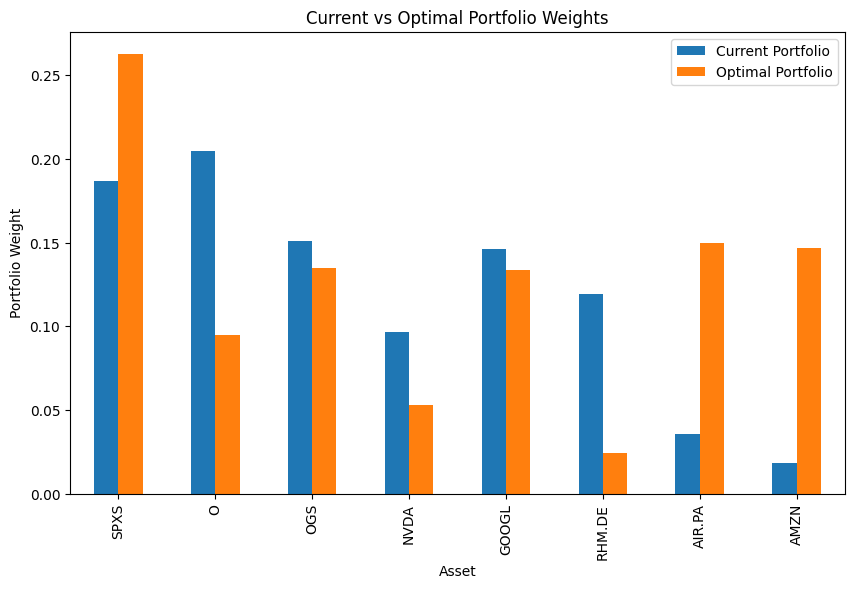

In [72]:
comparison.set_index("ticker")[["current_weight", "optimal_weight"]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Current vs Optimal Portfolio Weights")
plt.ylabel("Portfolio Weight")
plt.xlabel("Asset")
plt.legend(["Current Portfolio", "Optimal Portfolio"])

plt.show()

## 11. Estimate Expected Asset Returns

In order to compute the maximum Sharpe ratio portfolio, we first estimate the expected returns of each asset.

We approximate expected returns using the historical mean of daily returns and annualize them.

In [73]:
mean_returns = returns.mean() * 252
mean_returns

,0
Ticker,
AIR.PA,0.180397
AMZN,0.195340
GOOGL,0.287325
NVDA,0.670124
O,0.095372
OGS,0.086386
RHM.DE,0.501272
SPXS,-0.413987


## 12. Compute the Maximum Sharpe Ratio Portfolio

In this step, we compute the portfolio that maximizes the Sharpe ratio.

The Sharpe ratio measures return per unit of risk, so this optimization identifies the allocation that provides the best risk-adjusted return.

In [74]:
mu = mean_returns.values
Sigma = cov_matrix.values

w_sharpe = cp.Variable(n_assets)

objective = cp.Maximize(mu @ w_sharpe)

constraints_sharpe = [
    cp.sum(w_sharpe) == 1,
    w_sharpe >= 0.05,
    w_sharpe <= 0.30
]

problem_sharpe = cp.Problem(objective, constraints_sharpe)
problem_sharpe.solve()

np.float64(0.4016929525420672)

To avoid extreme concentration in a small number of assets, we impose allocation constraints.

Each asset must have a minimum weight of 5% and a maximum weight of 30%.

In [75]:
max_sharpe_weights = pd.DataFrame({
    "ticker": tickers,
    "max_sharpe_weight": w_sharpe.value
})

max_sharpe_weights = max_sharpe_weights.round(4)
max_sharpe_weights

,ticker,max_sharpe_weight
0,NVDA,0.05
1,GOOGL,0.05
2,AMZN,0.15
3,O,0.30
4,OGS,0.05
5,AIR.PA,0.05
6,RHM.DE,0.30
7,SPXS,0.05


## 13. Compare Portfolio Allocations

We now compare the three portfolio allocations:

- Current portfolio
- Minimum variance portfolio
- Maximum Sharpe ratio portfolio

This comparison highlights how the optimization models adjust asset allocations relative to the current portfolio.

In [76]:
comparison_all = comparison.merge(
    max_sharpe_weights,
    on="ticker",
    how="left"
)

comparison_all

,ticker,current_weight,optimal_weight,difference,max_sharpe_weight
0,SPXS,0.1867,0.2628,0.0761,0.05
1,O,0.2050,0.0948,-0.1102,0.30
2,OGS,0.1510,0.1350,-0.0160,0.05
3,NVDA,0.0968,0.0528,-0.0440,0.05
4,GOOGL,0.1463,0.1337,-0.0126,0.05
5,RHM.DE,0.1196,0.0243,-0.0953,0.30
6,AIR.PA,0.0360,0.1500,0.1140,0.05
7,AMZN,0.0187,0.1466,0.1279,0.15


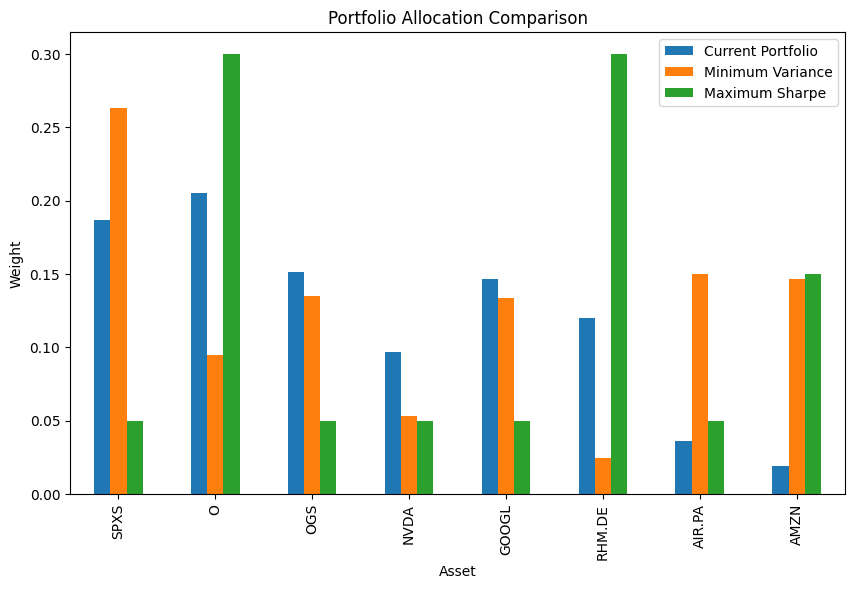

In [77]:
comparison_all.set_index("ticker")[
    ["current_weight", "optimal_weight", "max_sharpe_weight"]
].plot(kind="bar", figsize=(10,6))

plt.title("Portfolio Allocation Comparison")
plt.ylabel("Weight")
plt.xlabel("Asset")

plt.legend([
    "Current Portfolio",
    "Minimum Variance",
    "Maximum Sharpe"
])

plt.show()

## 14. Plot the Efficient Frontier

In this section, we construct and visualize the efficient frontier.

The efficient frontier represents the set of portfolios that deliver the highest expected return for each level of risk, subject to the portfolio constraints.

In [78]:
# Range of target annual returns used to build the efficient frontier
target_returns = np.linspace(mean_returns.min(), mean_returns.max(), 50)

# Store efficient frontier results
frontier_risk = []
frontier_return = []

# Convert pandas objects to NumPy arrays for CVXPY
mu = mean_returns.values
Sigma = cov_matrix.values

for target_return in target_returns:

    # Portfolio weights
    weights = cp.Variable(n_assets)

    # Portfolio expected return and variance
    expected_return = mu @ weights
    portfolio_variance = cp.quad_form(weights, Sigma)

    # Constraints
    constraints = [
        cp.sum(weights) == 1,
        weights >= 0.05,
        weights <= 0.30,
        expected_return >= target_return
    ]

    # Optimization problem: minimize variance for a given target return
    problem = cp.Problem(
        cp.Minimize(portfolio_variance),
        constraints
    )

    problem.solve()

    # Store results only if a valid solution exists
    if weights.value is not None:
        portfolio_risk = np.sqrt(weights.value.T @ Sigma @ weights.value)
        portfolio_ret = mu @ weights.value

        frontier_risk.append(portfolio_risk)
        frontier_return.append(portfolio_ret)

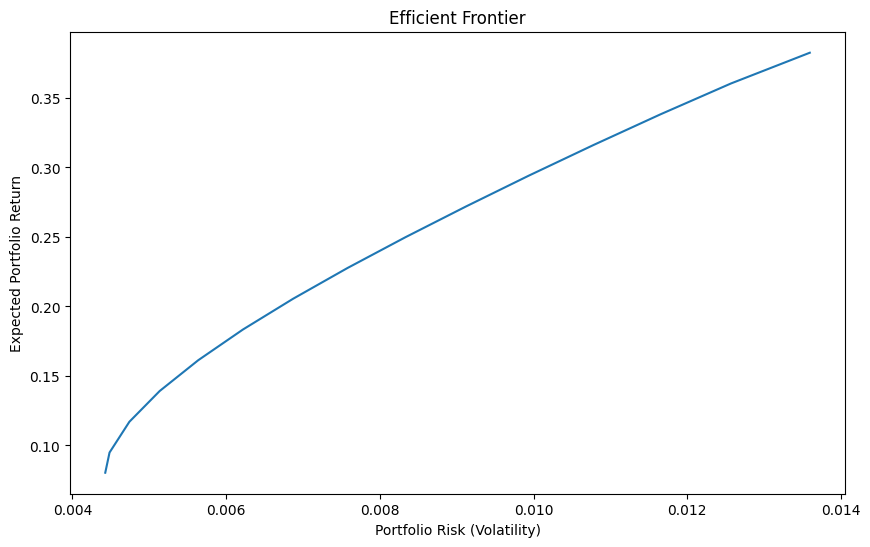

In [79]:
plt.figure(figsize=(10, 6))
plt.plot(frontier_risk, frontier_return)

plt.title("Efficient Frontier")
plt.xlabel("Portfolio Risk (Volatility)")
plt.ylabel("Expected Portfolio Return")

plt.show()

## 15. Highlight Portfolios on the Efficient Frontier

We now highlight three portfolios on the efficient frontier:

- Current portfolio
- Minimum variance portfolio
- Maximum Sharpe ratio portfolio

This allows us to visually compare the risk-return characteristics of the different allocations.

In [80]:
# Convert to arrays
mu = mean_returns.values
Sigma = cov_matrix.values

# Current portfolio weights
current_weights = comparison["current_weight"].values

# Minimum variance portfolio weights
min_var_weights = optimal_weights["optimal_weight"].values

# Maximum Sharpe portfolio weights
max_sharpe = max_sharpe_weights["max_sharpe_weight"].values


# Compute risk and return
def portfolio_metrics(weights):
    ret = mu @ weights
    risk = np.sqrt(weights.T @ Sigma @ weights)
    return risk, ret


current_risk, current_return = portfolio_metrics(current_weights)
minvar_risk, minvar_return = portfolio_metrics(min_var_weights)
sharpe_risk, sharpe_return = portfolio_metrics(max_sharpe)

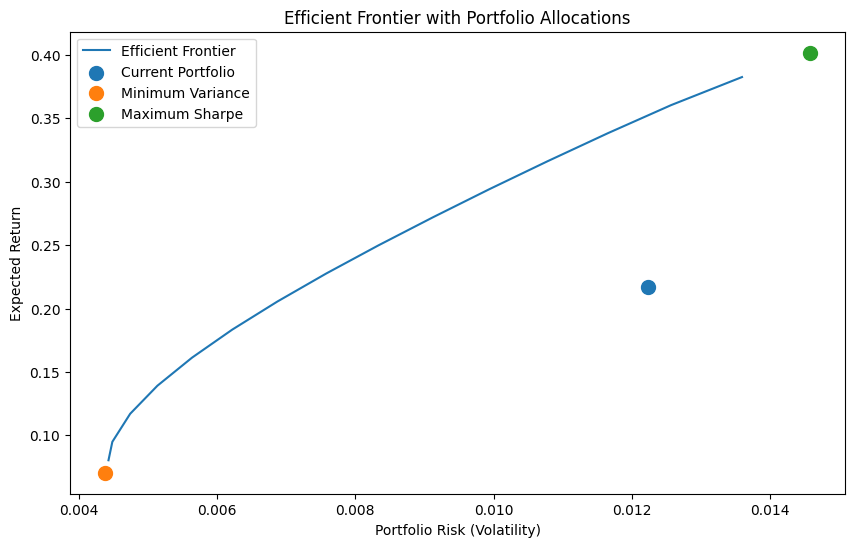

In [86]:
plt.figure(figsize=(10,6))

# Efficient frontier
plt.plot(frontier_risk, frontier_return, label="Efficient Frontier")

# Highlight portfolios
plt.scatter(current_risk, current_return, label="Current Portfolio", s=100)
plt.scatter(minvar_risk, minvar_return, label="Minimum Variance", s=100)
plt.scatter(sharpe_risk, sharpe_return, label="Maximum Sharpe", s=100)

plt.title("Efficient Frontier with Portfolio Allocations")
plt.xlabel("Portfolio Risk (Volatility)")
plt.ylabel("Expected Return")

plt.legend()
plt.savefig("efficient_frontier.png", dpi=300, bbox_inches="tight")
plt.show()

## 16. Portfolio Performance Metrics

In this section we compute the key performance metrics of each portfolio allocation.

We evaluate expected return, volatility, and Sharpe ratio for:

- Current portfolio
- Minimum variance portfolio
- Maximum Sharpe portfolio

In [82]:
def portfolio_metrics(weights):

    portfolio_return = mu @ weights

    # annualized volatility
    portfolio_volatility = np.sqrt(weights.T @ Sigma @ weights) * np.sqrt(252)

    sharpe_ratio = portfolio_return / portfolio_volatility

    return portfolio_return, portfolio_volatility, sharpe_ratio



In [83]:
current_metrics = portfolio_metrics(current_weights)
minvar_metrics = portfolio_metrics(min_var_weights)
sharpe_metrics = portfolio_metrics(max_sharpe)

In [84]:
metrics_table = pd.DataFrame({
    "Portfolio": ["Current", "Minimum Variance", "Maximum Sharpe"],
    "Expected Return": [
        current_metrics[0],
        minvar_metrics[0],
        sharpe_metrics[0]
    ],
    "Volatility": [
        current_metrics[1],
        minvar_metrics[1],
        sharpe_metrics[1]
    ],
    "Sharpe Ratio": [
        current_metrics[2],
        minvar_metrics[2],
        sharpe_metrics[2]
    ]
})

metrics_table = metrics_table.round(4)
metrics_table

metrics_table

,Portfolio,Expected Return,Volatility,Sharpe Ratio
0,Current,0.2166,0.1941,1.1156
1,Minimum Variance,0.0705,0.0695,1.0139
2,Maximum Sharpe,0.4017,0.2314,1.7360


## 17. Conclusion

This project implemented a portfolio optimization framework based on the Markowitz mean-variance model using my personal portfolio assets.

Using historical market data from Yahoo Finance, the analysis computed:

- daily asset returns
- covariance matrix
- minimum variance portfolio
- maximum Sharpe ratio portfolio
- efficient frontier
- portfolio performance metrics

The results show that the current portfolio can be compared against optimized allocations in terms of expected return, volatility, and Sharpe ratio.

Under the assumptions of the model and the imposed allocation constraints, the maximum Sharpe portfolio delivers the highest risk-adjusted return, while the minimum variance portfolio provides the lowest volatility.